In [2]:
%pip install numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 25.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 59.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 41.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# ---------- Load data ----------
scores = pd.read_csv("x_pca.csv")
loadings = pd.read_csv("pca_df.csv")
 
# If the first column is an unnamed index, treat it as the row label
if scores.columns[0].lower().startswith("unnamed"):
    scores = scores.set_index(scores.columns[0])
if loadings.columns[0].lower().startswith("unnamed") or loadings.dtypes.iloc[0] == object:
    loadings = loadings.set_index(loadings.columns[0])
 
# Pull the first two components from each frame (assumes PC1, PC2 are the first two numeric cols)
pc1_scores, pc2_scores = scores.iloc[:, 0].values, scores.iloc[:, 1].values
pc1_load,   pc2_load   = loadings.iloc[:, 0].values, loadings.iloc[:, 1].values
feature_names = loadings.index.astype(str)

# ---------- Scale loadings so the arrows fit the score cloud ----------
# Standard biplot trick: scale arrows to ~70% of the score range
score_range = max(pc1_scores.max() - pc1_scores.min(),
                  pc2_scores.max() - pc2_scores.min())
load_range = max(np.abs(pc1_load).max(), np.abs(pc2_load).max())
arrow_scale = 0.7 * score_range / load_range

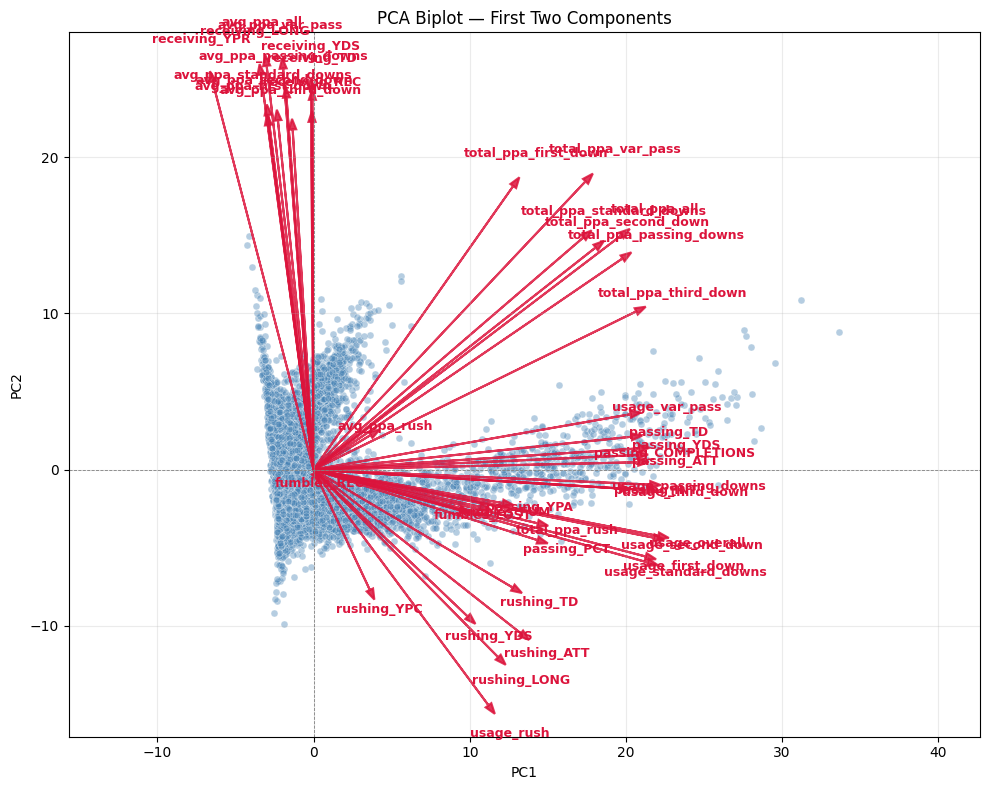

In [5]:
# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(10, 8))
 
# Scores as scatter
ax.scatter(pc1_scores, pc2_scores, alpha=0.4, s=25, color="steelblue",
           edgecolor="white", linewidth=0.5, label="Samples")
 
# Loadings as arrows + labels
for i, feat in enumerate(feature_names):
    x_end = pc1_load[i] * arrow_scale
    y_end = pc2_load[i] * arrow_scale
    ax.arrow(0, 0, x_end, y_end,
             color="crimson", alpha=0.85, head_width=score_range * 0.012,
             length_includes_head=True, linewidth=1.5)
    # Push the label a bit past the arrow tip
    label_pad = 1.08
    ax.text(x_end * label_pad, y_end * label_pad, feat,
            color="crimson", ha="center", va="center", fontsize=9,
            fontweight="bold")
 
# Reference axes through origin
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.6, linestyle="--")
 
ax.set_xlabel(f"{scores.columns[0]}")
ax.set_ylabel(f"{scores.columns[1]}")
ax.set_title("PCA Biplot — First Two Components")
ax.grid(alpha=0.25)
ax.set_aspect("equal", adjustable="datalim")
 
plt.tight_layout()
plt.savefig("biplot.png", dpi=200)
plt.show()